<a href="https://colab.research.google.com/github/sarvisonker-jpg/Diabetes_Predicition/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import RandomOverSampler

import joblib

In [ ]:
df = pd.read_csv("/content/archive (8).zip")

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
df.shape

(100000, 9)

In [ ]:
df.info

<bound method DataFrame.info of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              6.6                  140         0  
1              6.6                   80         0  
2              5.7                  158         0  
3              5.0                  155         0  
4              4.8                  155         0  
...            ...                  ...       ...  
99995          6.2                   90         0  
99996          6.5                  100         0  
99997          5.7                  155         0  
99998          4.0                  100         0  
99999          6.6                   90         0  

[100000 rows x 9 columns]>

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(3854)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(96146, 9)

In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

gender
['Female' 'Male' 'Other']
--------------------------------------------------
age
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
--------------------------------------------------
hypertension
[0 1]
--------------------------------------------------
heart_disease
[1 0]
--------------------------------------------------
smoking_history
['never' 'No Info' 'current' 'former' 'ever' 'not current']
--------------------------------

In [ ]:
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"])
df["smoking_history"] = le_smoking.fit_transform(df["smoking_history"])

/tmp/ipykernel_6389/3995777740.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"] = le_gender.fit_transform(df["gender"])
/tmp/ipykernel_6389/3995777740.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["smoking_history"] = le_smoking.fit_transform(df["smoking_history"])


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


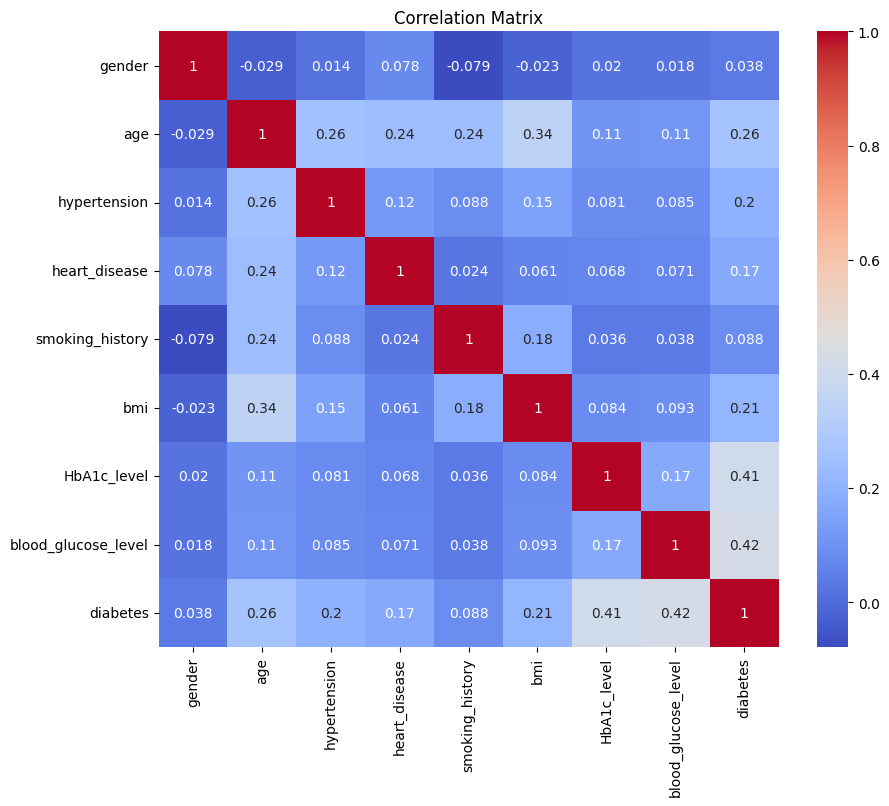

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [ ]:
y.value_counts()

,count
diabetes,
0,87664
1,8482


In [ ]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [ ]:
y_resampled.value_counts()

,count
diabetes,
0,87664
1,87664


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (140262, 8)
X_test : (35066, 8)
y_train: (140262,)
y_test : (35066,)


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.9840301146409628


In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     17439
           1       0.97      1.00      0.98     17627

    accuracy                           0.98     35066
   macro avg       0.98      0.98      0.98     35066
weighted avg       0.98      0.98      0.98     35066



In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[16879   560]
 [    0 17627]]


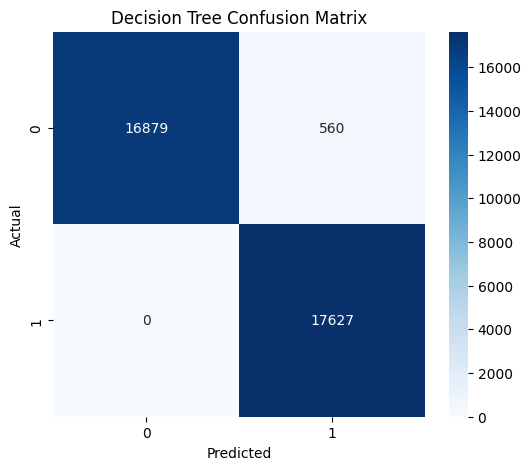

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9913876689670906


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     17439
           1       0.98      1.00      0.99     17627

    accuracy                           0.99     35066
   macro avg       0.99      0.99      0.99     35066
weighted avg       0.99      0.99      0.99     35066



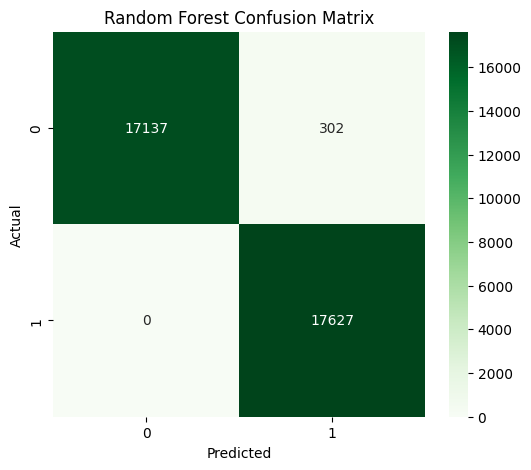

In [ ]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Example of a Simple ML Model: Logistic Regression

Logistic Regression is a linear model for binary classification. Despite its name, it's used for classification tasks rather than regression, by estimating the probability of a binary outcome. It's often considered a good baseline model due to its simplicity and interpretability.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

In [ ]:
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

In [ ]:
# Evaluate the Logistic Regression model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

print("Logistic Regression Accuracy :", log_reg_accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

log_reg_cm = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix:\n", log_reg_cm)

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    log_reg_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
params = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

In [ ]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
best_model = grid.best_estimator_

In [ ]:
final_pred = best_model.predict(X_test)

In [ ]:
final_accuracy = accuracy_score(
    y_test,
    final_pred
)

print("Final Accuracy :",final_accuracy)

Final Accuracy : 0.991330633662237


In [ ]:
joblib.dump(
    best_model,
    "diabetes_prediction_model.pkl"
)

['diabetes_prediction_model.pkl']

In [ ]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
gender = widgets.Dropdown(
    options=['Female','Male','Other'],
    description='Gender'
)

age = widgets.FloatText(
    description='Age'
)

hypertension = widgets.Dropdown(
    options=[0,1],
    description='Hypertension'
)

heart_disease = widgets.Dropdown(
    options=[0,1],
    description='Heart Disease'
)

smoking_history = widgets.Dropdown(
    options=['No Info','current','ever','former','never','not current'],
    description='Smoking'
)

bmi = widgets.FloatText(
    description='BMI'
)

hba1c = widgets.FloatText(
    description='HbA1c'
)

glucose = widgets.FloatText(
    description='Glucose'
)
button = widgets.Button(
    description='Predict Diabetes'
)

output = widgets.Output()

In [ ]:
def predict_diabetes(b):

    gender_val = le_gender.transform([gender.value])[0]

    smoking_val = le_smoking.transform([smoking_history.value])[0]

    sample = pd.DataFrame([[
        gender_val,
        age.value,
        hypertension.value,
        heart_disease.value,
        smoking_val,
        bmi.value,
        hba1c.value,
        glucose.value
    ]],
    columns=X.columns)

    prediction = best_model.predict(sample)

    with output:
        output.clear_output()

        if prediction[0] == 1:
            print("Diabetic")
        else:
            print("Not Diabetic")
            button.on_click(
    predict_diabetes
)

In [ ]:
display(
    gender,
    age,
    hypertension,
    heart_disease,
    smoking_history,
    bmi,
    hba1c,
    glucose,
    button,
    output
)

Dropdown(description='Gender', options=('Female', 'Male', 'Other'), value='Female')

FloatText(value=0.0, description='Age')

Dropdown(description='Hypertension', options=(0, 1), value=0)

Dropdown(description='Heart Disease', options=(0, 1), value=0)

Dropdown(description='Smoking', options=('No Info', 'current', 'ever', 'former', 'never', 'not current'), valu…

FloatText(value=0.0, description='BMI')

FloatText(value=0.0, description='HbA1c')

FloatText(value=0.0, description='Glucose')

Button(description='Predict Diabetes', style=ButtonStyle())

Output()